In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("C:/Users/MANI/Desktop/PYTHON/Project/trader_sentiment/data/sentiment.csv")
trades = pd.read_csv("C:/Users/MANI/Desktop/PYTHON/Project/trader_sentiment/data/trades.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [3]:
print("Sentiment Shape: ", sentiment.shape)
print("Trades Shape: ", trades.shape)

print("\nMissing Values:")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

Sentiment Shape:  (2644, 4)
Trades Shape:  (211224, 16)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
0
0


In [4]:
# Clean column names
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

# ✅ Correct timestamp conversion (VERY IMPORTANT)
trades["timestamp ist"] = pd.to_datetime(
    trades["timestamp ist"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Create correct date
trades["date"] = trades["timestamp ist"].dt.date

# Fix sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce").dt.date


print("Date conversion done")

Date conversion done


In [5]:
merged = pd.merge(trades, sentiment, on="date", how="left")
print(merged.head())

                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side       timestamp ist  start position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed pnl                                   transaction hash     order id  \
0         0

In [6]:
# Remove rows where classification or pnl missing
temp = merged.dropna(subset=["classification", "closed pnl"])

print(temp.shape)

(211218, 20)


In [7]:
# win
merged["win"] = merged["closed pnl"] > 0 

In [8]:
print(merged.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification', 'win'],
      dtype='object')


In [9]:
# Daily PnL
daily_pnl = merged.groupby(["date", "account"])["closed pnl"].sum().reset_index()

# Wining rate
win_rate = merged.groupby("account")["win"].mean()

# number of trades in a day
trades_per_day = merged.groupby("date").size()

# size of average trade
avg_size = merged.groupby("account")["size tokens"].mean()

print(daily_pnl.head())

         date                                     account  closed pnl
0  2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000
1  2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000
2  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737
3  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034
4  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000


In [10]:
# Fear VS Greed PnL
print(merged.groupby("classification")["closed pnl"].mean())

# Total trades
print(merged.groupby("classification").size())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed pnl, dtype: float64
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


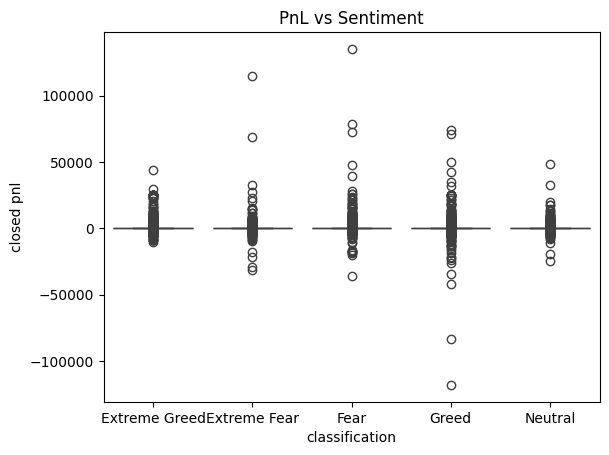

In [11]:
# Convert to numeric (safe)
merged["closed pnl"] = pd.to_numeric(merged["closed pnl"], errors="coerce")

# Remove bad rows
temp = merged.dropna(subset=["closed pnl", "classification"])

# Plot
sns.boxplot(x="classification", y="closed pnl", data=temp)
plt.title("PnL vs Sentiment")
plt.show()

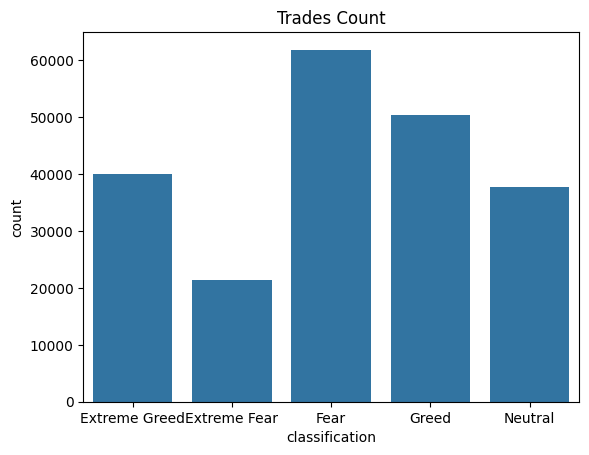

In [12]:
sns.countplot(x="classification", data=temp)
plt.title("Trades Count")
plt.show()

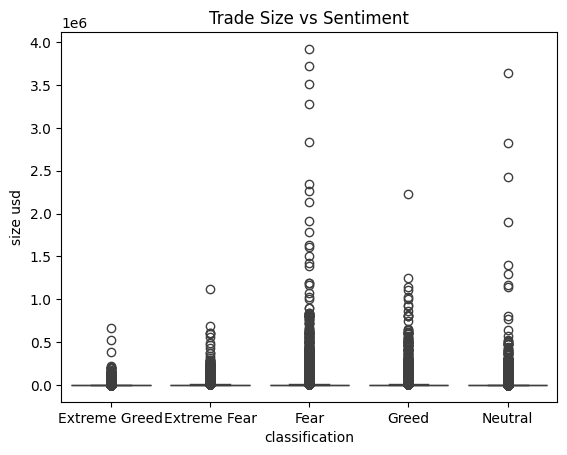

In [13]:
# Convert to numeric
merged["size usd"] = pd.to_numeric(merged["size usd"], errors="coerce")

# Clean data
temp = merged.dropna(subset=["size usd", "classification"])

# Plot
sns.boxplot(x="classification", y="size usd", data=temp)
plt.title("Trade Size vs Sentiment")
plt.show()

In [14]:
plt.savefig("C:/Users/MANI/Desktop/PYTHON/Project/trader_sentiment/output/pnl_chart.png")

<Figure size 640x480 with 0 Axes>

In [15]:
print(temp.shape)
print(temp.head())

(211218, 21)
                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side       timestamp ist  start position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed pnl  ...     order id  crossed       fee      trade id  \
0         0